# ブートストラップSHAP: 合成データによる統制実証

`mean|SHAP|`（絶対寄与の平均）は一次モーメント要約なので、ヘビーテールな寄与分布に脆い。
**「大多数のサンプルでは寄与ほぼ0、ごく一部の外れ値でだけ巨大な寄与」を持つ特徴**が過剰に高くランクされる。

真の重要度が既知の合成データで、この弱点と、ブートストラップ（毎回モデル再学習）による
信頼度（変動係数 CV / 95%CI）の可視化・再ランキングが機能することを裏取りする。

In [1]:
import numpy as np, pandas as pd, shap, matplotlib.pyplot as plt
from xgboost import XGBRegressor
from scipy import stats

plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.grid":True,
                     "grid.alpha":0.3,"axes.axisbelow":True})
C_OUT="#d1495b"; C_OK="#4c72b0"; C_NOISE="#9aa0a6"
N, B, SEED = 6000, 50, 42

/home/kohei/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 合成データ生成

- `x1,x2,x3` … 全サンプルに広く効く（真に重要）。係数 1.0 / 0.8 / 0.6。
- `x_out` … **外れ値検出専用**。効果は `|x_out|>2.5`（約1%）のときだけ `25*x_out` として発火。
- `x_noise` … 効果なし（負のコントロール）。

In [2]:
def make_synth(n, seed):
    rng = np.random.default_rng(seed)
    x1=rng.normal(size=n); x2=rng.normal(size=n); x3=rng.normal(size=n)
    x_out=rng.normal(size=n); x_noise=rng.normal(size=n)
    fire=(np.abs(x_out)>2.5).astype(float)              # ~1% のサンプルだけ発火
    y=1.0*x1+0.8*x2+0.6*x3 + 25.0*x_out*fire + rng.normal(scale=0.5,size=n)
    X=pd.DataFrame({"x1":x1,"x2":x2,"x3":x3,"x_out":x_out,"x_noise":x_noise})
    return X, y, fire

X, y, fire = make_synth(N, SEED)
cols=list(X.columns)
print(f"x_out が発火するのは全体の {100*fire.mean():.2f}%")
X.describe().round(2)

x_out が発火するのは全体の 1.13%


,x1,x2,x3,x_out,x_noise
count,6000.00,6000.00,6000.00,6000.00,6000.00
mean,-0.01,-0.01,0.02,0.03,0.01
std,1.00,1.01,1.00,1.00,1.01
min,-4.39,-3.53,-3.89,-3.70,-3.53
25%,-0.68,-0.68,-0.66,-0.64,-0.67
50%,0.01,-0.04,0.00,0.03,0.03
75%,0.64,0.66,0.69,0.71,0.69
max,3.45,4.15,3.20,3.56,3.68


## SHAP計算とブートストラップ手法

XGBRegressorを学習し、TreeExplainerで `mean|SHAP|` を求める。ブートストラップは**毎回モデルを再学習**する。

In [3]:
def fit(X, y, seed):
    return XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=seed, n_jobs=4).fit(X, y)

def abs_shap(model, X):
    return np.abs(shap.TreeExplainer(model).shap_values(X))   # (n_samples, n_features)

def bootstrap(X, y, B, seed):
    rng=np.random.default_rng(seed); n=len(X)
    out=np.zeros((B, X.shape[1]))
    for b in range(B):
        idx=rng.integers(0, n, n)                       # 行を復元抽出
        m=fit(X.iloc[idx].reset_index(drop=True), y[idx], b+1)
        out[b]=abs_shap(m, X.iloc[idx].reset_index(drop=True)).mean(0)
    return out

def summarize(boot, cols):
    m=boot.mean(0); sd=boot.std(0)
    df=pd.DataFrame({"mean":m,"sd":sd,"cv":sd/m,
        "ci_lo":np.percentile(boot,2.5,0),"ci_hi":np.percentile(boot,97.5,0)}, index=cols)
    df["adj"]=df["mean"]/(1+df["cv"])                   # 信頼度調整重要度
    return df

### まず「標準」の単発SHAP

1回だけ学習した通常の `mean|SHAP|`。ここで **x_out がどう評価されるか** に注目。

In [4]:
m0=fit(X,y,0); A0=abs_shap(m0,X)
std =pd.Series(A0.mean(0),   index=cols)
med =pd.Series(np.median(A0,0), index=cols)
trim=pd.Series(stats.trim_mean(A0,0.1,axis=0), index=cols)
print("標準 mean|SHAP| ランキング:", list(std.sort_values(ascending=False).index))
std.sort_values(ascending=False).round(4)

標準 mean|SHAP| ランキング: ['x_out', 'x1', 'x2', 'x3', 'x_noise']


x_out      0.8192
x1         0.8153
x2         0.6746
x3         0.4700
x_noise    0.0645
dtype: float32

→ 1%でしか効かないはずの **x_out が最上位**に来る（過剰評価）。分布を見る beeswarm では、x_out の巨大寄与が少数の点に集中していることが分かる。

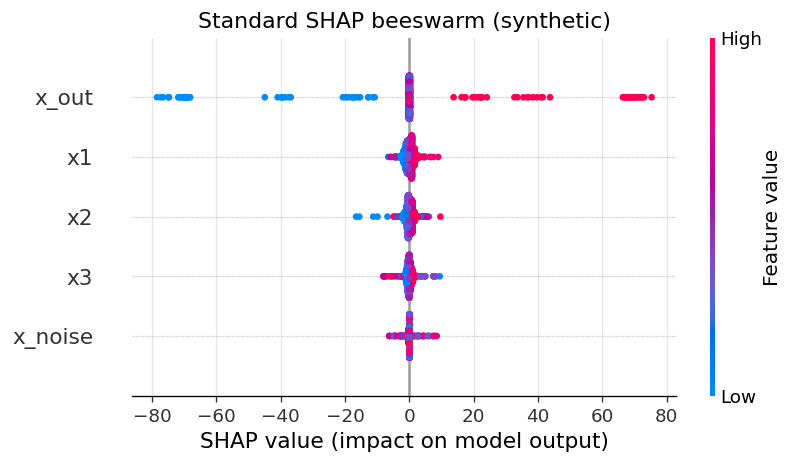

In [5]:
sv=shap.TreeExplainer(m0).shap_values(X)
shap.summary_plot(sv, X, show=False, plot_size=(7,4))
plt.title("Standard SHAP beeswarm (synthetic)")
plt.tight_layout(); plt.savefig("img/syn_beeswarm.png", bbox_inches="tight"); plt.show()

### ブートストラップSHAP（B=50, 毎回再学習）

In [6]:
boot=bootstrap(X,y,B,SEED)
S=summarize(boot,cols)
print("標準ランク   :", list(std.sort_values(ascending=False).index))
print("信頼度調整ランク:", list(S["adj"].sort_values(ascending=False).index))
S.sort_values("mean",ascending=False).round(4)

標準ランク   : ['x_out', 'x1', 'x2', 'x3', 'x_noise']
信頼度調整ランク: ['x1', 'x_out', 'x2', 'x3', 'x_noise']


,mean,sd,cv,ci_lo,ci_hi,adj
x_out,0.8606,0.0959,0.1115,0.6712,1.0010,0.7743
x1,0.8217,0.0231,0.0282,0.7845,0.8675,0.7992
x2,0.6736,0.0209,0.0310,0.6371,0.7224,0.6533
x3,0.4841,0.0161,0.0332,0.4573,0.5194,0.4685
x_noise,0.0600,0.0212,0.3539,0.0294,0.1019,0.0443


x_out は **mean は最大だが CV が広域特徴の約4倍**・95%CIも広い。
信頼度調整（`mean/(1+CV)`）では x1 が正しく首位に戻り、x_out は降格する。

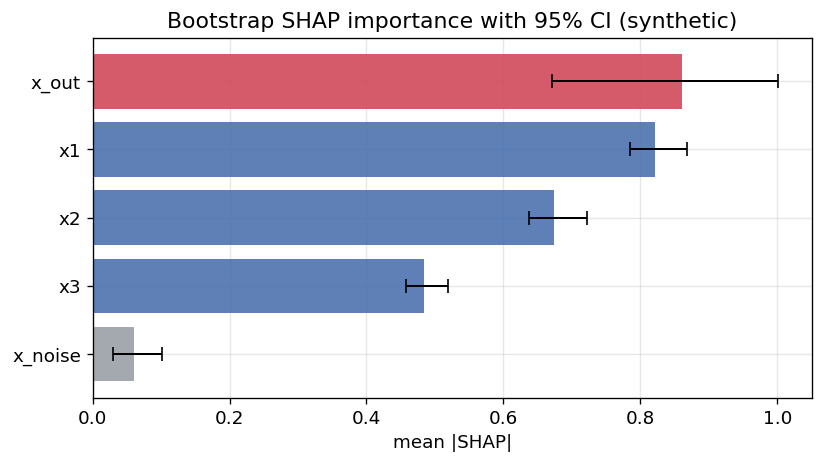

In [7]:
# 図2: mean|SHAP| + 95%CI エラーバー
order=list(std.sort_values(ascending=False).index)
oc=[C_OUT if c=="x_out" else (C_NOISE if c=="x_noise" else C_OK) for c in order]
yv=np.arange(len(order))[::-1]; means=S.loc[order,"mean"].values
err=np.vstack([means-S.loc[order,"ci_lo"].values, S.loc[order,"ci_hi"].values-means])
fig,ax=plt.subplots(figsize=(7,4))
ax.barh(yv,means,color=oc,alpha=.9)
ax.errorbar(means,yv,xerr=err,fmt="none",ecolor="black",capsize=4,lw=1.2)
ax.set_yticks(yv); ax.set_yticklabels(order); ax.set_xlabel("mean |SHAP|")
ax.set_title("Bootstrap SHAP importance with 95% CI (synthetic)")
plt.tight_layout(); plt.savefig("img/syn_bar_ci.png",bbox_inches="tight"); plt.show()

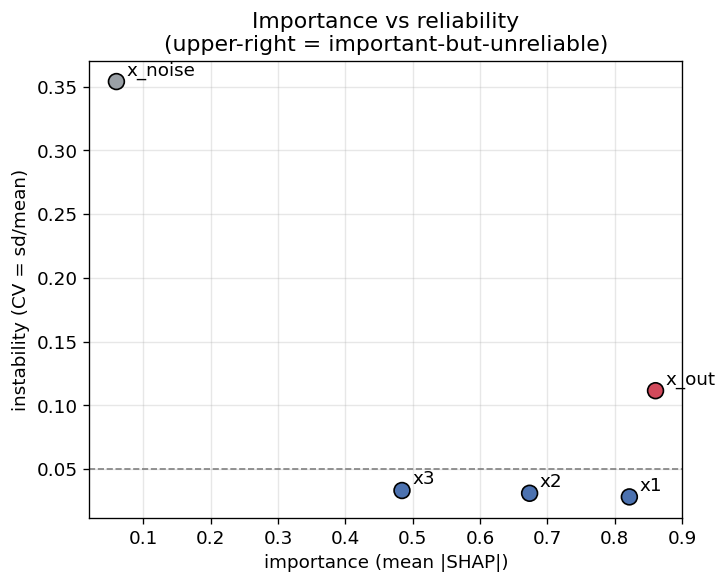

In [8]:
# 図3: 重要度 vs 信頼度(CV) 散布図
color=[C_OUT if c=="x_out" else (C_NOISE if c=="x_noise" else C_OK) for c in cols]
fig,ax=plt.subplots(figsize=(6.2,5))
ax.scatter(S["mean"],S["cv"],c=color,s=90,edgecolor="k",zorder=3)
for c in cols: ax.annotate(c,(S.loc[c,"mean"],S.loc[c,"cv"]),xytext=(6,4),textcoords="offset points")
ax.axhline(0.05,ls="--",c="gray",lw=1)
ax.set_xlabel("importance (mean |SHAP|)"); ax.set_ylabel("instability (CV = sd/mean)")
ax.set_title("Importance vs reliability\n(upper-right = important-but-unreliable)")
plt.tight_layout(); plt.savefig("img/syn_scatter.png",bbox_inches="tight"); plt.show()

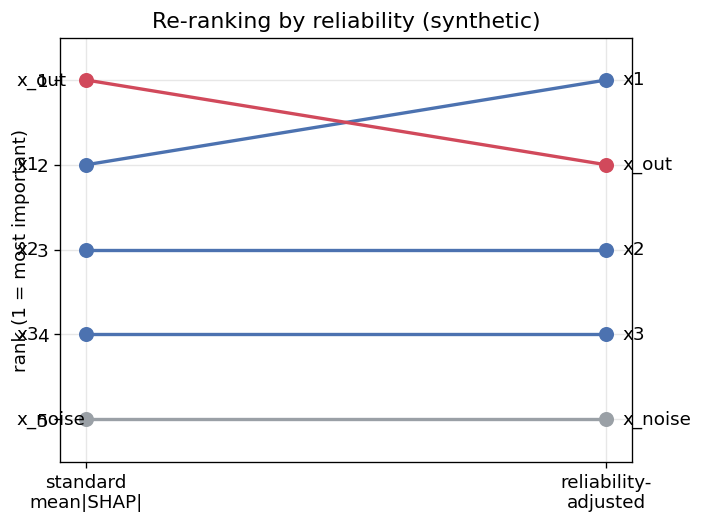

In [9]:
# 図4: 再ランキング（標準 → 信頼度調整）
r_std=std.rank(ascending=False); r_adj=S["adj"].rank(ascending=False)
fig,ax=plt.subplots(figsize=(6,4.5))
for c in cols:
    cc=C_OUT if c=="x_out" else (C_NOISE if c=="x_noise" else C_OK)
    ax.plot([0,1],[r_std[c],r_adj[c]],"-o",color=cc,lw=2,ms=8)
    ax.annotate(c,(0,r_std[c]),xytext=(-42,-3),textcoords="offset points")
    ax.annotate(c,(1,r_adj[c]),xytext=(10,-3),textcoords="offset points")
ax.set_xticks([0,1]); ax.set_xticklabels(["standard\nmean|SHAP|","reliability-\nadjusted"])
ax.set_ylim(len(cols)+.5,.5); ax.set_ylabel("rank (1 = most important)")
ax.set_title("Re-ranking by reliability (synthetic)")
plt.tight_layout(); plt.savefig("img/syn_rank.png",bbox_inches="tight"); plt.show()

/tmp/ipykernel_361280/297472258.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  comp=(comp/comp.sum(0)).loc[order]


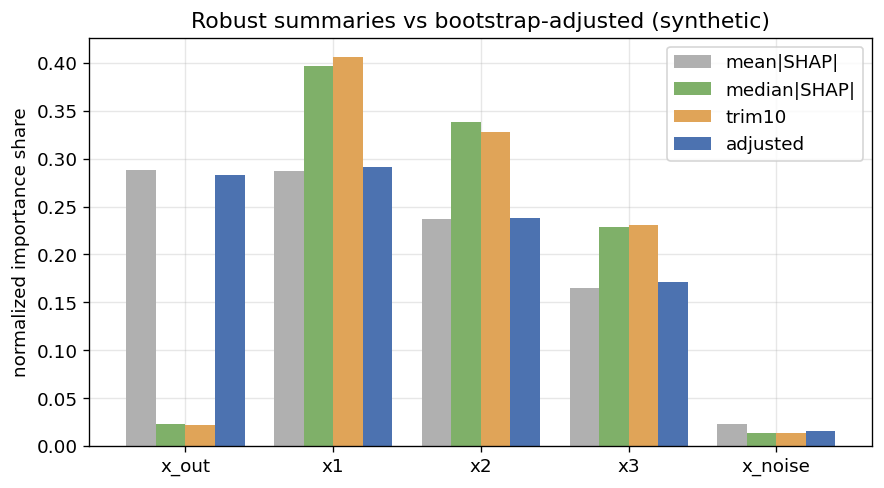

In [10]:
# 図5: ロバスト要約との比較（正規化シェア）
comp=pd.DataFrame({"mean|SHAP|":std,"median|SHAP|":med,"trim10":trim,"adjusted":S["adj"]})
comp=(comp/comp.sum(0)).loc[order]
fig,ax=plt.subplots(figsize=(7.5,4.2))
comp.plot(kind="bar",ax=ax,width=.8,color=["#b0b0b0","#7fb069","#e0a458","#4c72b0"])
ax.set_ylabel("normalized importance share")
ax.set_title("Robust summaries vs bootstrap-adjusted (synthetic)")
ax.set_xticklabels(order,rotation=0)
plt.tight_layout(); plt.savefig("img/syn_baselines.png",bbox_inches="tight"); plt.show()
S.to_csv("data/syn_summary.csv")

## まとめ（合成）

| 指標 | x_out の扱い |
|---|---|
| 標準 `mean\|SHAP\|` | **1位（過剰評価）** |
| CV（変動係数） | 広域特徴の約4倍 → 低信頼を検出 |
| 信頼度調整ランク | x1 の下へ降格 |
| `median\|SHAP\|`（ベースライン） | 下位へ（順位は直るが信頼度は不明） |

真の重要度が既知の設定で、**ブートストラップCV/CIは「外れ値でしか効かない特徴」を低信頼として炙り出し、
再ランキングで是正できる**ことが確認できた。次はこれを実データ（JEPX）に適用する。